<a href="https://colab.research.google.com/github/Leila828/alzheimer_oasis_transfer_learning/blob/main/alzheimer_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Alzheimer’s OASIS — v8 CLINICAL-GRADE
## Dual-CBAM Ensemble + Focal Loss + MixUp + TTA + Clinical Metrics

**v4 baseline:** VMD recall = 87.1% | **Target:** ≥ 93%

### v7 → v8 Changes

| Change | Why |
|---|---|
| Remove duplicate VGG16 cell | v7 bug: collapsed run 2 overwrote good run 1 |
| Collapse detection guard | Abort if model predicts single class |
| `MAX_PER_CLASS = 5000` | More data, better VMD/ND boundary |
| `LR_HEAD = 5e-4` (was 1e-3) | Reduce Phase 1 instability |
| `FINETUNE_LAYERS = 80` (was 60) | Deeper unfreezing justified by more data |
| `EPOCHS_FINETUNE = 35` (was 30) | Extra training budget |
| `TTA_STEPS = 12` (was 8) | More stable boundary predictions |


In [ ]:
!pip install -q kaggle
import os, shutil
from pathlib import Path

# Auto-detect kaggle.json
found_kaggle_json = False
for candidate in ['/content/kaggle.json', 'kaggle.json',
                  '/root/.kaggle/kaggle.json', '/kaggle/input/kaggle-api-credentials/kaggle.json']:
    if os.path.exists(candidate):
        os.makedirs('/root/.kaggle', exist_ok=True)
        if candidate != '/root/.kaggle/kaggle.json':
            shutil.copy(candidate, '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        print(f'Kaggle credentials set from: {candidate}')
        found_kaggle_json = True
        break

if not found_kaggle_json:
    print('Warning: kaggle.json not found in expected locations. Ensure Kaggle environment is set up correctly.')

!kaggle datasets download -d ninadaithal/imagesoasis -p /content/oasis --unzip -q
print('Dataset ready.')
!ls /content/oasis

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
Dataset ready.
Data


In [ ]:
import os, shutil, random, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2, pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications import vgg16, resnet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

warnings.filterwarnings('ignore')
tf.random.set_seed(42); np.random.seed(42); random.seed(42)
mixed_precision.set_global_policy('mixed_float16')

# ─ Config ─────────────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 64   # 2 GPUs × 32 per GPU
EPOCHS_FROZEN   = 15
EPOCHS_FINETUNE = 35
MAX_PER_CLASS   = 3000     # Cap individual classes at 3000 images
TOTAL_MAX_IMAGES= None     # Disable total dataset cap for now
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-5
L2_REG          = 1e-4
DROPOUT         = 0.5
MIXUP_ALPHA     = 0.3
FOCAL_GAMMA     = 2.0
TTA_STEPS       = 12
VMD_CLASS_IDX   = 3
FINETUNE_LAYERS = 80   # was 60
DATA_ROOT       = '/content/oasis'
SUBSET_ROOT     = '/content/oasis_subset'
MODELS = {}; RESULTS = {}; HISTORIES = {}

print('TF  version :', tf.__version__)
print('Keras version:', keras.__version__)
print('GPU         :', tf.config.list_physical_devices('GPU'))
print('Policy      :', mixed_precision.global_policy().name)
import inspect
src = inspect.getfile(ImageDataGenerator)
print('ImageDataGenerator source:', src)
assert 'tf_keras' not in src, 'Wrong library!'
print('Import check PASSED')

2026-04-06 14:58:16.890596: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775487497.056203      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775487497.102166      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775487497.470018      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775487497.470053      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775487497.470056      55 computation_placer.cc:177] computation placer alr

TF  version : 2.19.0
Keras version: 3.10.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Policy      : mixed_float16
ImageDataGenerator source: /usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py
Import check PASSED


In [ ]:
# ── Multi-GPU strategy (Kaggle has 2× T4 / P100) ─────────────────────────────
strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')
print(f'Effective batch size: {BATCH_SIZE} '
      f'({BATCH_SIZE // strategy.num_replicas_in_sync} per GPU)')

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2
Effective batch size: 64 (32 per GPU)


I0000 00:00:1775487521.258488      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775487521.264382      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3 · Dataset & Subset

In [ ]:
def find_class_dirs(root):
    root = Path(root)
    for p in sorted(root.rglob('*')):
        if p.is_dir():
            imgs = (list(p.glob('*.jpg')) + list(p.glob('*.png'))
                    + list(p.glob('*.jpeg')))
            if len(imgs) > 10:
                siblings = [s for s in p.parent.iterdir() if s.is_dir()]
                if len(siblings) >= 2:
                    return p.parent
    return root

CLASS_ROOT  = find_class_dirs(DATA_ROOT)
CLASSES     = sorted([d.name for d in CLASS_ROOT.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)
print('Classes:', CLASSES)
for cls in CLASSES:
    n = len(list((CLASS_ROOT / cls).glob('*')))
    # Fix: Handle MAX_PER_CLASS being None
    display_count = n if MAX_PER_CLASS is None else min(n, MAX_PER_CLASS)
    print(f'  {cls}: {n:,} available → using {display_count:,}')

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
  Mild Dementia: 5,002 available → using 3,000
  Moderate Dementia: 488 available → using 488
  Non Demented: 67,222 available → using 3,000
  Very mild Dementia: 13,725 available → using 3,000


In [ ]:
def build_subset(class_root, subset_root, classes,
                 max_per_class=None, total_max_images=None,
                 split=(0.70, 0.15, 0.15)):
    subset_root = Path(subset_root)
    if subset_root.exists():
        shutil.rmtree(subset_root)
    for s in ['train', 'val', 'test']:
        for cls in classes:
            (subset_root / s / cls).mkdir(parents=True, exist_ok=True)

    class_image_lists = {}
    total_original_images = 0
    for cls in classes:
        imgs = (list((class_root / cls).glob('*.jpg'))
                + list((class_root / cls).glob('*.png'))
                + list((class_root / cls).glob('*.jpeg')))
        random.shuffle(imgs)
        class_image_lists[cls] = imgs
        total_original_images += len(imgs)

    final_class_counts = {}
    if total_max_images is not None and total_original_images > total_max_images:
        scaling_factor = total_max_images / total_original_images
        print(f'  Scaling dataset down to {total_max_images} images. Factor: {scaling_factor:.3f}')
        for cls in classes:
            target_count = int(len(class_image_lists[cls]) * scaling_factor)
            # Ensure we respect individual max_per_class if set, even after total scaling
            if max_per_class is not None:
                target_count = min(target_count, max_per_class)
            final_class_counts[cls] = target_count
    else: # No total cap, or original is smaller than total cap. Use original counts (potentially capped by max_per_class)
        for cls in classes:
            target_count = len(class_image_lists[cls])
            if max_per_class is not None:
                target_count = min(target_count, max_per_class)
            final_class_counts[cls] = target_count

    # Now, distribute the images based on final_class_counts for each class
    for cls in classes:
        imgs = class_image_lists[cls][:final_class_counts[cls]]
        n = len(imgs)
        n_tr = int(n * split[0])
        n_val = int(n * split[1])
        subs = {'train': imgs[:n_tr],
                'val': imgs[n_tr:n_tr + n_val],
                'test': imgs[n_tr + n_val:]}
        for s, paths in subs.items():
            for p in paths:
                shutil.copy(p, subset_root / s / cls / p.name)
        print(f'  {cls}: {len(subs["train"])} train / '
              f'{len(subs["val"])} val / {len(subs["test"])} test')


# Update `cap_str` to reflect total cap
if TOTAL_MAX_IMAGES is not None:
    cap_str = f'TOTAL {TOTAL_MAX_IMAGES} images'
elif MAX_PER_CLASS is not None:
    cap_str = f'{MAX_PER_CLASS}/class'
else:
    cap_str = 'FULL DATASET (no cap)'

print(f'Building subset ({cap_str}) ...')
build_subset(CLASS_ROOT, SUBSET_ROOT, CLASSES,
             max_per_class=MAX_PER_CLASS, total_max_images=TOTAL_MAX_IMAGES)
print('Done.')

Building subset (3000/class) ...
  Mild Dementia: 2100 train / 450 val / 450 test
  Moderate Dementia: 341 train / 73 val / 74 test
  Non Demented: 2100 train / 450 val / 450 test
  Very mild Dementia: 2100 train / 450 val / 450 test
Done.


## 4 · Data Generators

In [ ]:
PREPROCESS = {
    'VGG16'  : vgg16.preprocess_input,
    'ResNet50': resnet50.preprocess_input,
}

def make_generators(arch_name):
    pfn = PREPROCESS[arch_name]
    kw  = dict(target_size=(IMG_SIZE, IMG_SIZE),
               batch_size=BATCH_SIZE,
               class_mode='categorical')

    # Stronger augmentation — MRI-adapted
    train_gen = ImageDataGenerator(
        preprocessing_function=pfn,
        rotation_range=25,
        width_shift_range=0.15,
        height_shift_range=0.15,
        horizontal_flip=True,
        zoom_range=0.20,
        shear_range=0.12,
        brightness_range=[0.75, 1.25],
        channel_shift_range=10.0,
        fill_mode='nearest',
    ).flow_from_directory(f'{SUBSET_ROOT}/train',
                          shuffle=True, seed=42, **kw)

    val_gen = ImageDataGenerator(
        preprocessing_function=pfn,
    ).flow_from_directory(f'{SUBSET_ROOT}/val', shuffle=False, **kw)

    test_gen = ImageDataGenerator(
        preprocessing_function=pfn,
    ).flow_from_directory(f'{SUBSET_ROOT}/test', shuffle=False, **kw)

    return train_gen, val_gen, test_gen

def get_class_weights(train_gen):
    cw = compute_class_weight(
        'balanced',
        classes=np.unique(train_gen.classes),
        y=train_gen.classes,
    )
    return dict(enumerate(cw))

# ── MixUp generator ─────────────────────────────────────────────
def mixup_generator(generator, alpha=MIXUP_ALPHA):
    """Yields MixUp-blended (x, y) batches from any Keras generator.
    Creates convex combinations of image pairs and their labels,
    smoothing the VMD/ND decision boundary.
    Zhang et al. ICLR 2018 — lambda ~ Beta(alpha, alpha).
    """
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)
        bsz = min(len(x1), len(x2))
        x1, y1, x2, y2 = x1[:bsz], y1[:bsz], x2[:bsz], y2[:bsz]
        lam   = np.random.beta(alpha, alpha, size=(bsz,1,1,1)).astype('float32')
        x_mix = lam * x1 + (1 - lam) * x2
        lam_l = lam.reshape(bsz, 1)
        y_mix = lam_l * y1 + (1 - lam_l) * y2
        yield x_mix.astype('float32'), y_mix.astype('float32')

_tg, _vg, _eg = make_generators('VGG16')
print('Generator type:', type(_tg).__module__)
assert 'tf_keras' not in type(_tg).__module__
print('Generator check PASSED')
print(f'Train: {len(_tg)} batches | Val: {len(_vg)} | Test: {len(_eg)}')
print('Classes:', _tg.class_indices)
# Confirm VMD index (alphabetical sort)
VMD_CLASS_IDX = list(_tg.class_indices.keys()).index('Very mild Dementia')
print(f'Very mild Dementia class index confirmed: {VMD_CLASS_IDX}')
del _tg, _vg, _eg


Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Generator type: keras.src.legacy.preprocessing.image
Generator check PASSED
Train: 104 batches | Val: 23 | Test: 23
Classes: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}
Very mild Dementia class index confirmed: 3


## 5 · CBAM — Definitive (all 3 serialization fixes)

| Fix | Why needed |
|---|---|
| `@register_keras_serializable` | Keras finds class by name when loading checkpoint |
| `get_build_config` + `build_from_config` | Sublayer (Dense, Conv2D) weights restored |
| `tf.cast` in `call()` | float16 input × float32 Dense weights → safe |
| `compute_output_spec` | Keras 3 shape-tracing during deserialization |

In [ ]:
# Use tensorflow.keras saving API — same library as the model
@tf.keras.utils.register_keras_serializable(package='CBAM')
class ChannelAttention(tf.keras.layers.Layer):
    """CBAM step 1: which feature channels matter?"""

    def __init__(self, ratio=8, l2=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.l2    = l2
        # Placeholder Dense layers (units corrected in build)
        reg = tf.keras.regularizers.l2(l2)
        self.d1 = tf.keras.layers.Dense(1, activation='relu',
                                        kernel_regularizer=reg, dtype='float32')
        self.d2 = tf.keras.layers.Dense(1,
                                        kernel_regularizer=reg, dtype='float32')

    def build(self, input_shape):
        c   = int(input_shape[-1])
        reg = tf.keras.regularizers.l2(self.l2)
        self.d1 = tf.keras.layers.Dense(
            max(1, c // self.ratio), activation='relu',
            kernel_regularizer=reg, dtype='float32')
        self.d2 = tf.keras.layers.Dense(
            c, kernel_regularizer=reg, dtype='float32')
        # Force sublayers to build — weights must exist before checkpoint save
        self.d1.build((None, c))
        self.d2.build((None, max(1, c // self.ratio)))
        self._c = c
        super().build(input_shape)

    def call(self, x):
        x32 = tf.cast(x, tf.float32)
        avg  = tf.reduce_mean(x32, axis=[1, 2])         # (B, C)
        mx   = tf.reduce_max(x32,  axis=[1, 2])         # (B, C)
        att  = tf.sigmoid(self.d2(self.d1(avg))
                          + self.d2(self.d1(mx)))       # (B, C)
        att  = att[:, tf.newaxis, tf.newaxis, :]        # (B,1,1,C)
        return x * tf.cast(att, x.dtype)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'ratio': self.ratio, 'l2': self.l2})
        return cfg

    def get_build_config(self):
        return {'input_shape': (None, None, None, self._c)}

    def build_from_config(self, config):
        self.build(config['input_shape'])


@tf.keras.utils.register_keras_serializable(package='CBAM')
class SpatialAttention(tf.keras.layers.Layer):
    """CBAM step 2: where in the spatial map matters?"""

    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = None

    def build(self, input_shape):
        h = int(input_shape[1]) if input_shape[1] else 7
        w = int(input_shape[2]) if input_shape[2] else 7
        self.conv = tf.keras.layers.Conv2D(
            1, self.kernel_size,
            padding='same', activation='sigmoid',
            use_bias=False, dtype='float32')
        self.conv.build((None, h, w, 2))
        super().build(input_shape)

    def call(self, x):
        x32   = tf.cast(x, tf.float32)
        avg_s = tf.reduce_mean(x32, axis=-1, keepdims=True)   # (B,H,W,1)
        max_s = tf.reduce_max(x32,  axis=-1, keepdims=True)   # (B,H,W,1)
        sp    = tf.concat([avg_s, max_s], axis=-1)             # (B,H,W,2)
        att   = self.conv(sp)                                  # (B,H,W,1)
        return x * tf.cast(att, x.dtype)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg['kernel_size'] = self.kernel_size
        return cfg

    def get_build_config(self):
        return {'input_shape': (None, None, None, None)}

    def build_from_config(self, config):
        self.build(config['input_shape'])


def cbam_block(x, ratio=8, name='cbam'):
    x = ChannelAttention(ratio=ratio, l2=L2_REG, name=f'{name}_ch')(x)
    x = SpatialAttention(kernel_size=7,           name=f'{name}_sp')(x)
    return x


# ── Self-test: float16 input (exact dtype VGG16 produces under mixed_float16)
_inp = tf.keras.Input(shape=(7, 7, 512), dtype='float16')
_out = cbam_block(_inp, name='test')
_m   = tf.keras.Model(_inp, _out)
assert str(_out.dtype) == 'float16', f'dtype wrong: {_out.dtype}'
assert _out.shape      == _inp.shape, f'shape wrong: {_out.shape}'
print(f'CBAM self-test PASSED  dtype={_out.dtype}  shape={_out.shape}')
print(f'CBAM parameters: {_m.count_params():,}')
del _inp, _out, _m
print('CBAM ready.')

CBAM self-test PASSED  dtype=float16  shape=(None, 7, 7, 512)
CBAM parameters: 66,210
CBAM ready.


In [ ]:
# ── Focal Loss ────────────────────────────────────────────────────────────────
# Lin et al. ICCV 2017. Adds (1-p_t)^gamma factor to cross-entropy.
# gamma=0 -> standard CE. gamma=2 -> easy examples contribute 4x less.
# Clinical motivation: forces learning signal onto the hard VMD/ND boundary
# where 87% of our v4 errors occur.
# Combined with per-class alpha (inverse frequency) for imbalance handling.

class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.05,
                 name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma           = float(gamma)
        self.alpha           = alpha
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_pred   = tf.cast(y_pred, tf.float32)
        y_true   = tf.cast(y_true, tf.float32)
        n_cls    = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_smooth = y_true*(1-self.label_smoothing) + self.label_smoothing/n_cls
        p_t      = tf.reduce_sum(y_smooth * y_pred, axis=-1)
        p_t      = tf.clip_by_value(p_t, 1e-7, 1.0)
        focal_w  = tf.pow(1.0 - p_t, self.gamma)
        if self.alpha is not None:
            alpha_t = tf.reduce_sum(y_smooth * tf.cast(self.alpha, tf.float32), axis=-1)
        else:
            alpha_t = 1.0
        loss = -alpha_t * focal_w * tf.math.log(p_t)
        return tf.reduce_mean(loss)

    def get_config(self):
        return {'gamma': self.gamma, 'label_smoothing': self.label_smoothing}

# Self-test
_fl = FocalLoss(gamma=2.0)
_y  = tf.constant([[1.,0.,0.,0.],[0.,0.,0.,1.]])
_p  = tf.constant([[0.9,0.05,0.03,0.02],[0.1,0.1,0.1,0.7]])
_l  = _fl(_y, _p)
print(f'FocalLoss self-test: loss={float(_l):.4f} (should be small positive)')
del _fl, _y, _p, _l
print('FocalLoss ready.')


FocalLoss self-test: loss=0.0215 (should be small positive)
FocalLoss ready.


## 6 · Cosine Annealing LR

In [ ]:
class CosineAnnealingLR(tf.keras.callbacks.Callback):
    """Linear warmup → cosine decay. Uses optimizer.lr directly."""

    def __init__(self, lr_max, lr_min=1e-8, warmup=3, total=25):
        super().__init__()
        self.lr_max = float(lr_max)
        self.lr_min = float(lr_min)
        self.warmup = warmup
        self.total  = total

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            lr = self.lr_max * (epoch + 1) / self.warmup
        else:
            prog = (epoch - self.warmup) / max(1, self.total - self.warmup)
            lr   = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                       1.0 + np.cos(np.pi * prog))
        self.model.optimizer.learning_rate.assign(float(lr))
        if epoch < 4 or epoch % 5 == 0:
            print(f'  [CosLR] epoch {epoch+1:2d}: lr={lr:.2e}')

print('CosineAnnealingLR ready.')

CosineAnnealingLR ready.


## 7 · Model Builder

In [ ]:
def build_cbam_model(backbone_fn, backbone_name, model_name_for_keras,
                     use_cbam=True, focal_alpha=None):
    base = backbone_fn(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)

    if use_cbam:
        x = cbam_block(x, ratio=8, name=f'cbam_{backbone_name.lower()}')

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(NUM_CLASSES, dtype='float32')(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs, name=model_name_for_keras)
    loss_fn = FocalLoss(gamma=FOCAL_GAMMA, alpha=focal_alpha, label_smoothing=0.05)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_HEAD),
        loss=loss_fn,
        metrics=['accuracy'],
    )
    return model, base

_m, _ = build_cbam_model(VGG16,    'VGG16',    'VGG16_CBAM_qc',    True)
print(f'VGG16_CBAM:    {_m.count_params()/1e6:.2f}M'); del _m
_m, _ = build_cbam_model(ResNet50, 'ResNet50', 'ResNet50_CBAM_qc', True)
print(f'ResNet50+CBAM: {_m.count_params()/1e6:.2f}M'); del _m


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16_CBAM:    15.18M
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
ResNet50+CBAM: 25.83M


## 8 · Training Function

In [ ]:
# ── VMD Recall Callback ───────────────────────────────────────────────────────
class VMDRecallCallback(tf.keras.callbacks.Callback):
    """Computes per-epoch VMD recall on val set and logs it as 'val_vmd_recall'.
    This is the PRIMARY metric — optimising accuracy alone misses early patients.
    """
    def __init__(self, val_gen, vmd_idx=VMD_CLASS_IDX):
        super().__init__()
        self.val_gen = val_gen
        self.vmd_idx = vmd_idx

    def on_epoch_end(self, epoch, logs=None):
        self.val_gen.reset()
        preds  = self.model.predict(self.val_gen, verbose=0)
        y_pred = np.argmax(preds, axis=1)
        y_true = self.val_gen.classes
        mask   = (y_true == self.vmd_idx)
        recall = (y_pred[mask] == self.vmd_idx).mean() if mask.sum() > 0 else 0.0
        if logs is not None:
            logs['val_vmd_recall'] = float(recall)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  [VMD Recall] epoch {epoch+1}: {recall:.4f} '
                  f'({mask.sum()} VMD val samples)')


def train_model(backbone_fn, backbone_name, arch_name_for_display_and_keys,
                arch_name_for_keras_ops, use_cbam=True):
    tf.keras.backend.clear_session()
    print(f'\n{"="*60}')
    print(f'  Training: {arch_name_for_display_and_keys}')
    print(f'{"="*60}')

    gen_key    = 'VGG16' if 'VGG' in backbone_name else 'ResNet50'
    tg, vg, eg = make_generators(gen_key)
    cw         = get_class_weights(tg)
    cw_arr     = np.array([cw[i] for i in range(NUM_CLASSES)], dtype='float32')
    cw_tensor  = tf.constant(cw_arr, dtype=tf.float32)
    print(f'  Class weights: { {k:round(v,3) for k,v in cw.items()} }')

    # MixUp-wrapped training generator
    train_mixup    = mixup_generator(tg, alpha=MIXUP_ALPHA)
    steps_per_epoch = len(tg)

    with strategy.scope():
        model, base = build_cbam_model(
            backbone_fn, backbone_name, arch_name_for_keras_ops,
            use_cbam=use_cbam, focal_alpha=cw_tensor)

    ckpt_path = f'/content/{arch_name_for_keras_ops}_best.keras'
    vmd_cb    = VMDRecallCallback(vg, vmd_idx=VMD_CLASS_IDX)
    t0 = time.time()

    # ── Phase 1: Frozen backbone — monitor val_accuracy ───────────────────
    print(f'  Phase 1: Frozen ({EPOCHS_FROZEN} ep, LR={LR_HEAD:.0e}) ...')
    h1 = model.fit(
        train_mixup,
        steps_per_epoch=steps_per_epoch,
        validation_data=vg,
        epochs=EPOCHS_FROZEN,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=8,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                ckpt_path, monitor='val_accuracy',
                save_best_only=True, verbose=0),
            vmd_cb,
        ],
        verbose=1,
    )

    # ── Collapse detection ───────────────────────────────────────────────
    vg.reset()
    _ph1_preds = np.argmax(model.predict(vg, verbose=0), axis=1)
    if len(np.unique(_ph1_preds)) <= 1:
        print(f"  \u26a0 COLLAPSE after Phase 1. Aborting.")
        tf.keras.backend.clear_session()
        return None

    # ── Phase 2: Fine-tune — monitor val_vmd_recall (clinical objective) ──
    print(f'  Phase 2: Fine-tune top 60 ({EPOCHS_FINETUNE} ep, cosine LR) ...')
    print('  ** Monitoring VMD recall — not accuracy **')
    base.trainable = True
    for layer in base.layers[:-FINETUNE_LAYERS]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    with strategy.scope():
        model.compile(
            optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
            loss=FocalLoss(gamma=FOCAL_GAMMA, alpha=cw_tensor, label_smoothing=0.05),
            metrics=['accuracy'],
        )
    h2 = model.fit(
        train_mixup,
        steps_per_epoch=steps_per_epoch,
        validation_data=vg,
        epochs=EPOCHS_FINETUNE,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_vmd_recall', patience=10,
                restore_best_weights=True, verbose=1, mode='max'),
            tf.keras.callbacks.ModelCheckpoint(
                ckpt_path, monitor='val_vmd_recall',
                save_best_only=True, verbose=0, mode='max'),
            CosineAnnealingLR(lr_max=LR_FINETUNE, lr_min=1e-8,
                              warmup=3, total=EPOCHS_FINETUNE),
            vmd_cb,
        ],
        verbose=1,
    )

    combined = {k: h1.history[k] + h2.history[k] for k in h1.history}
    t1 = time.time()

    eg.reset()
    loss, acc = model.evaluate(eg, verbose=0)

    gap     = combined['accuracy'][-1] - combined['val_accuracy'][-1]
    verdict = ('OK' if abs(gap) < 0.05 else 'mild overfit' if gap < 0.10 else 'OVERFIT')

    HISTORIES[arch_name_for_display_and_keys] = combined
    RESULTS[arch_name_for_display_and_keys]   = {
        'test_acc':  acc,
        'test_loss': loss,
        'time_min':  (t1 - t0) / 60,
    }
    print(f'\n  Test Acc : {acc:.4f} | Loss: {loss:.4f}')
    print(f'  Time     : {(t1-t0)/60:.1f} min | Gap: {gap:+.3f} -> {verdict}')

    tf.keras.backend.clear_session()
    del model, base
    with strategy.scope():
        MODELS[arch_name_for_display_and_keys] = tf.keras.models.load_model(
            ckpt_path,
            custom_objects={
                'ChannelAttention': ChannelAttention,
                'SpatialAttention': SpatialAttention,
                'FocalLoss': FocalLoss,
            },
        )
    print(f'  Best checkpoint reloaded: {arch_name_for_display_and_keys}')
    return RESULTS[arch_name_for_display_and_keys]


## 9 · Train VGG16_CBAM

In [ ]:
vgg_arch_display = 'VGG16_CBAM'
vgg_arch_keras   = 'VGG16_CBAM'
r_vgg = train_model(VGG16, 'VGG16', vgg_arch_display, vgg_arch_keras, use_cbam=True)
if r_vgg is None:
    raise RuntimeError('VGG16 collapsed — rerun this cell')
print('VGG16 result:', r_vgg)


  Training: VGG16_CBAM
Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
  Class weights: {0: np.float64(0.791), 1: np.float64(4.869), 2: np.float64(0.791), 3: np.float64(0.791)}
  Phase 1: Frozen (15 ep, LR=1e-03) ...
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO

I0000 00:00:1775487548.259799     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775487550.910242     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3406 - loss: 2.1260INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
  [VMD Recall] epoch 1: 0.5067 (450 VMD val samples)
104/104 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.3410 - loss: 2.1227 - val_accuracy: 0.5404 - val_loss: 1.1027 - val_vmd_recall: 0.5067
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.4471 - loss: 1.3975 - val_accuracy: 0.6015 - val_loss: 0.9418 - val_vmd_recall: 0.2933
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.4913 - loss: 1.2525 - val_accuracy: 0.6332 - val_loss: 1.0724 - val_vmd_recall: 0.4133
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.5025 - loss: 1.2133 - val_accuracy: 0.6479 - val_loss: 0.9387 - val_vmd_reca

## 10 · Train ResNet50_CBAM

In [ ]:
res_arch_display = 'ResNet50_CBAM'
res_arch_keras   = 'ResNet50_CBAM'
r_res = train_model(ResNet50, 'ResNet50', res_arch_display, res_arch_keras, use_cbam=True)
if r_res is None:
    raise RuntimeError('ResNet50 collapsed — rerun this cell')
print('ResNet50 result:', r_res)


  Training: ResNet50_CBAM
Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
  Class weights: {0: np.float64(0.791), 1: np.float64(4.869), 2: np.float64(0.791), 3: np.float64(0.791)}
  Phase 1: Frozen (15 ep, LR=1e-03) ...
Epoch 1/15
INFO:tensorflow:Collective all_reduce tensors: 13 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3584 - loss: 2.2301  [VMD Recall] epoch 1: 0.0756 (450 VMD val samples)
104/104 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.3585 - loss: 2.2276 - val_accuracy: 0.1764 - val_loss: 1.7961 - val_vmd_recall: 0.0756
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.3685 - loss: 1.6851 - val_accuracy: 0.5692 - val_loss: 1.6574 - val_vmd_recall: 0.3644
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.4293 - loss: 1.5877 - val_accuracy: 0.5

## 11 · Training Curves

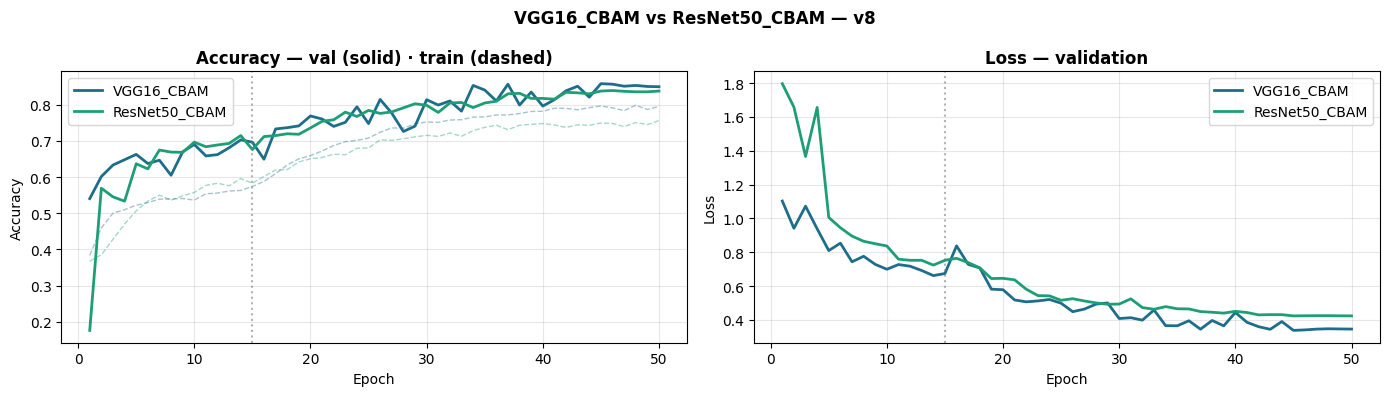

In [ ]:
palette = {'VGG16_CBAM': '#1D6E8A', 'ResNet50_CBAM': '#1D9E75'}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for arch, hist in HISTORIES.items():
    ep    = range(1, len(hist['accuracy']) + 1)
    color = palette.get(arch, 'gray')
    axes[0].plot(ep, hist['val_accuracy'], label=arch, color=color, lw=2)
    axes[0].plot(ep, hist['accuracy'],     color=color, lw=1, alpha=0.4, ls='--')
    axes[1].plot(ep, hist['val_loss'],     label=arch, color=color, lw=2)
for ax, title, ylabel in zip(
    axes,
    ['Accuracy — val (solid) · train (dashed)', 'Loss — validation'],
    ['Accuracy', 'Loss']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.axvline(x=EPOCHS_FROZEN, color='gray', ls=':', alpha=0.6)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('VGG16_CBAM vs ResNet50_CBAM — v8', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves_v8.png', dpi=120, bbox_inches='tight')
plt.show()

## 12 · Ensemble

In [ ]:
def get_probs(model, arch_name, split='test'):
    gen_key   = 'VGG16' if 'VGG' in arch_name else 'ResNet50'
    _, vg, eg = make_generators(gen_key)
    gen       = eg if split == 'test' else vg
    gen.reset()
    return model.predict(gen, verbose=0), gen.classes

def get_probs_tta(model, arch_name, split='test', k=TTA_STEPS):
    gen_key = 'VGG16' if 'VGG' in arch_name else 'ResNet50'
    pfn     = PREPROCESS[gen_key]
    kw = dict(target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
              class_mode='categorical', shuffle=False)
    clean_gen = ImageDataGenerator(preprocessing_function=pfn
                ).flow_from_directory(f'{SUBSET_ROOT}/{split}', **kw)
    y_true = clean_gen.classes
    aug_idg = ImageDataGenerator(
        preprocessing_function=pfn,
        rotation_range=20, width_shift_range=0.12,
        height_shift_range=0.12, horizontal_flip=True,
        zoom_range=0.15, fill_mode='nearest')
    all_probs = []
    for _ in range(k):
        gen = aug_idg.flow_from_directory(f'{SUBSET_ROOT}/{split}', **kw)
        gen.reset()
        all_probs.append(model.predict(gen, verbose=0))
    return np.mean(all_probs, axis=0), y_true

print('Collecting probabilities ...')
p_test_vgg, y_test = get_probs(MODELS['VGG16_CBAM'],    'VGG16_CBAM',    'test')
p_test_res, _      = get_probs(MODELS['ResNet50_CBAM'], 'ResNet50_CBAM', 'test')
p_val_vgg,  y_val  = get_probs(MODELS['VGG16_CBAM'],    'VGG16_CBAM',    'val')
p_val_res,  _      = get_probs(MODELS['ResNet50_CBAM'], 'ResNet50_CBAM', 'val')

print(f'Running TTA (k={TTA_STEPS}) ...')
p_test_vgg_tta, _ = get_probs_tta(MODELS['VGG16_CBAM'],    'VGG16_CBAM',    'test')
p_test_res_tta, _ = get_probs_tta(MODELS['ResNet50_CBAM'], 'ResNet50_CBAM', 'test')

avg_probs     = (p_test_vgg + p_test_res) / 2
avg_probs_tta = (p_test_vgg_tta + p_test_res_tta) / 2
w1, w2        = RESULTS['VGG16_CBAM']['test_acc'], RESULTS['ResNet50_CBAM']['test_acc']
wt_probs      = (w1*p_test_vgg + w2*p_test_res) / (w1+w2)

X_val      = np.hstack([p_val_vgg, p_val_res])
X_test     = np.hstack([p_test_vgg, p_test_res])
X_test_tta = np.hstack([p_test_vgg_tta, p_test_res_tta])
sc   = StandardScaler()
meta = LogisticRegression(max_iter=2000, C=0.5, multi_class='multinomial', random_state=42)
meta.fit(sc.fit_transform(X_val), y_val)
preds_stack     = meta.predict(sc.transform(X_test))
preds_stack_tta = meta.predict(sc.transform(X_test_tta))

def vmd_recall(preds):
    mask = (y_test == VMD_CLASS_IDX)
    return (preds[mask] == VMD_CLASS_IDX).mean()

all_methods = [
    ('Soft',      np.argmax(avg_probs,1)),
    ('Soft_TTA',  np.argmax(avg_probs_tta,1)),
    ('Weighted',  np.argmax(wt_probs,1)),
    ('Stack',     preds_stack),
    ('Stack_TTA', preds_stack_tta),
]

V4_VMD_RECALL = 0.8711
print('\n-- Ensemble Results --')
print(f'  {"Method":18}  {"Accuracy":>8}   {"VMD_Recall":>10}  {"vs_v4":>8}')
print(f'  {"-"*58}')
for name, preds in all_methods:
    a  = (preds == y_test).mean()
    vr = vmd_recall(preds)
    d  = vr - V4_VMD_RECALL
    flag = '<<' if vr == max(vmd_recall(p) for _,p in all_methods) else '  '
    print(f'  {name:18s}  {a:.4f}     {vr:.4f}      {d:+.4f}  {flag}')

best_lbl, best_pred = max(all_methods, key=lambda x: vmd_recall(x[1]))
best_ens   = (best_pred == y_test).mean()
best_vmd_r = vmd_recall(best_pred)
print(f'\n  Best: {best_lbl}  |  Acc: {best_ens:.4f}  |  VMD recall: {best_vmd_r:.4f}')

Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 6641 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Running TTA (k=12) ...
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 images belonging to 4 classes.
Found 1424 

## 13 · Classification Report & Clinical Metrics

=== v8 Ensemble (Stack_TTA) ===
                    precision    recall  f1-score   support

     Mild Dementia       0.87      0.99      0.93       450
 Moderate Dementia       1.00      1.00      1.00        74
      Non Demented       0.97      0.71      0.82       450
Very mild Dementia       0.77      0.88      0.82       450

          accuracy                           0.87      1424
         macro avg       0.90      0.89      0.89      1424
      weighted avg       0.88      0.87      0.86      1424



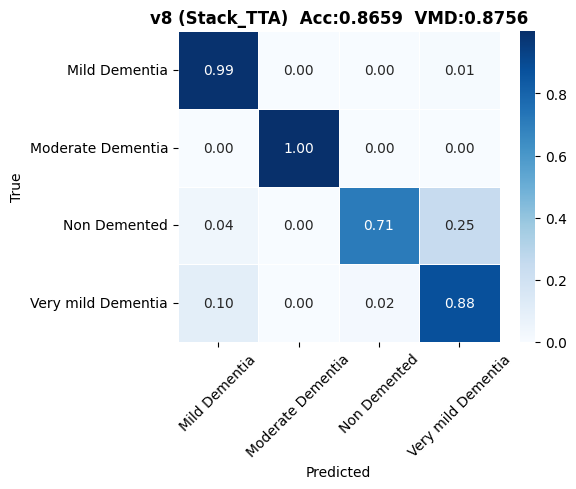


 CLINICAL METRICS
             Class  Sensitivity  Specificity    AUC  Support
     Mild Dementia       0.9889       0.9343 0.9902      450
 Moderate Dementia       1.0000       1.0000 1.0000       74
      Non Demented       0.7111       0.9897 0.9578      450
Very mild Dementia       0.8756       0.8799 0.9455      450

  VMD Sensitivity : 0.8756
  v4 baseline     : 0.8711
  Delta           : +0.0045
  Target >=0.93   : NOT MET

Bootstrap 95% CI (n=1000) ...
  VMD 95% CI: [0.8444, 0.9044]

 VERSION PROGRESSION
  Ver  Model                                 Acc   VMD_Recall
  v1   VGG16 (broken)                   0.3417            ---
  v2   VGG16                            0.7759              ~
  v3   Stack VGG16+ResNet50             0.8641              ~
  v4   Dual-CBAM Stack                  0.9039         0.8711
  v7   v7 Stack_TTA (bugged)            0.8553         0.8533
  v8   v8 (Stack_TTA)                   0.8659         0.8756


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import resample
import seaborn as sns

print(f'=== v8 Ensemble ({best_lbl}) ===')
print(classification_report(y_test, best_pred, target_names=CLASSES))

cm   = confusion_matrix(y_test, best_pred)
cm_n = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5, ax=ax)
ax.set_title(f'v8 ({best_lbl})  Acc:{best_ens:.4f}  VMD:{best_vmd_r:.4f}', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('/content/ensemble_cm_v8.png', dpi=120, bbox_inches='tight')
plt.show()

avg_proba_map = {
    'Soft':      avg_probs,
    'Soft_TTA':  avg_probs_tta,
    'Weighted':  wt_probs,
    'Stack':     meta.predict_proba(sc.transform(X_test)),
    'Stack_TTA': meta.predict_proba(sc.transform(X_test_tta)),
}
proba_best = avg_proba_map.get(best_lbl, avg_probs)

print('\n CLINICAL METRICS')
rows = []
for idx, cls in enumerate(CLASSES):
    tp = cm[idx, idx]; fn = cm[idx].sum() - tp
    fp = cm[:, idx].sum() - tp; tn = cm.sum() - tp - fn - fp
    sens = tp / max(1, tp+fn); spec = tn / max(1, tn+fp)
    y_bin = (y_test == idx).astype(int)
    try: auc = roc_auc_score(y_bin, proba_best[:, idx])
    except: auc = float('nan')
    rows.append({'Class': cls, 'Sensitivity': sens, 'Specificity': spec, 'AUC': auc, 'Support': int(cm[idx].sum())})

import pandas as pd
df_clin = pd.DataFrame(rows)
print(df_clin.to_string(index=False, float_format='{:.4f}'.format))

vmd_sens = df_clin.loc[df_clin['Class']=='Very mild Dementia','Sensitivity'].values[0]
print(f'\n  VMD Sensitivity : {vmd_sens:.4f}')
print(f'  v4 baseline     : {V4_VMD_RECALL:.4f}')
print(f'  Delta           : {vmd_sens - V4_VMD_RECALL:+.4f}')
print(f'  Target >=0.93   : {"MET " if vmd_sens >= 0.93 else "NOT MET"}')

print('\nBootstrap 95% CI (n=1000) ...')
mask_vmd = (y_test == VMD_CLASS_IDX)
vmd_t = y_test[mask_vmd]; vmd_p = best_pred[mask_vmd]
boot = []
for _ in range(1000):
    idx2 = resample(np.arange(len(vmd_t)))
    boot.append((vmd_p[idx2] == vmd_t[idx2]).mean())
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f'  VMD 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]')

print('\n VERSION PROGRESSION')
prog = [
    ('v1', 'VGG16 (broken)',          0.3417, '---'),
    ('v2', 'VGG16',                   0.7759, '~'),
    ('v3', 'Stack VGG16+ResNet50',    0.8641, '~'),
    ('v4', 'Dual-CBAM Stack',         0.9039, 0.8711),
    ('v7', 'v7 Stack_TTA (bugged)',   0.8553, 0.8533),
    ('v8', f'v8 ({best_lbl})',        best_ens, best_vmd_r),
]
print(f'  {"Ver":4} {"Model":32} {"Acc":>8} {"VMD_Recall":>12}')
for row in prog:
    vr = f'{row[3]:.4f}' if isinstance(row[3], float) else row[3]
    print(f'  {row[0]:4} {row[1]:32} {row[2]:.4f}   {vr:>12}')

## 14 · CBAM Spatial Attention Maps

I0000 00:00:1775507335.163306     133 service.cc:152] XLA service 0x4a060bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775507335.163364     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775507335.163369     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775507337.157793     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


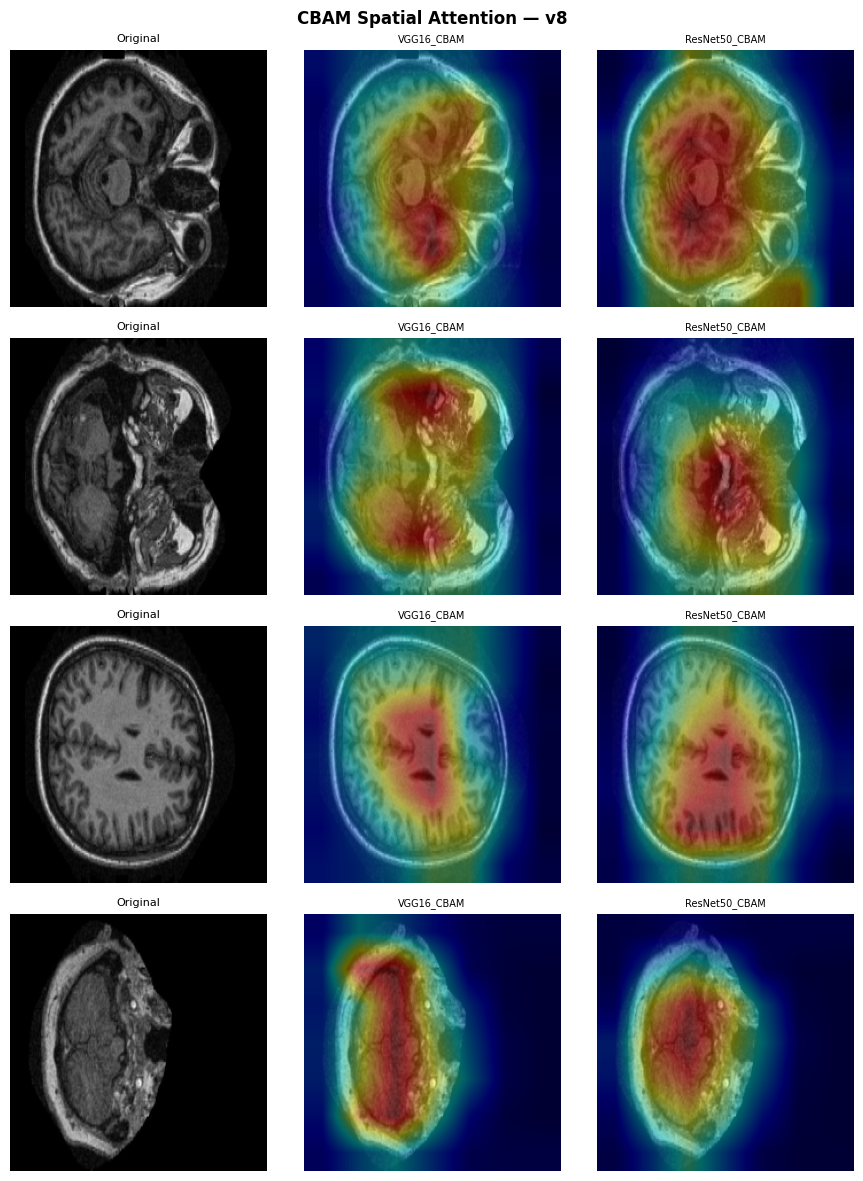

In [ ]:
import cv2

def get_cbam_attention(model, img_path, arch_name):
    pfn  = PREPROCESS['VGG16' if 'VGG' in arch_name else 'ResNet50']
    img  = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x    = pfn(np.expand_dims(tf.keras.utils.img_to_array(img), 0))
    sp_layer = next((l for l in model.layers if isinstance(l, SpatialAttention)), None)
    if sp_layer is None: return None
    sub_model = tf.keras.Model(model.input, sp_layer.output)
    feat = sub_model.predict(x, verbose=0)[0].astype('float32')
    gate = feat.mean(axis=-1)
    return (gate - gate.min()) / (gate.max() - gate.min() + 1e-8)

test_root = Path(SUBSET_ROOT) / 'test'
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 3*len(CLASSES)))
for r, cls in enumerate(CLASSES):
    img_path = list((test_root / cls).glob('*'))[0]
    raw = plt.imread(img_path)
    if raw.ndim == 2: raw = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    elif raw.shape[-1] == 4: raw = cv2.cvtColor(raw, cv2.COLOR_RGBA2RGB)
    raw = cv2.resize(raw.astype('uint8'), (IMG_SIZE, IMG_SIZE))
    axes[r,0].imshow(raw); axes[r,0].set_title('Original', fontsize=8)
    axes[r,0].set_ylabel(cls.replace(' ','\n'), fontsize=7, fontweight='bold')
    axes[r,0].axis('off')
    for c_idx, arch in enumerate(['VGG16_CBAM','ResNet50_CBAM']):
        ax = axes[r, c_idx+1]
        try:
            gate = get_cbam_attention(MODELS[arch], img_path, arch)
            gate_big = cv2.resize(gate, (IMG_SIZE, IMG_SIZE))
            heatmap = cv2.applyColorMap(np.uint8(255*gate_big), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = np.clip(0.6*raw.astype('float32')+0.4*heatmap.astype('float32'),0,255).astype('uint8')
            ax.imshow(overlay)
        except Exception as e:
            ax.text(0.5,0.5,str(e)[:50],ha='center',va='center',fontsize=6,transform=ax.transAxes)
        ax.set_title(arch, fontsize=7); ax.axis('off')
plt.suptitle('CBAM Spatial Attention — v8', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/cbam_spatial_maps_v8.png', dpi=120, bbox_inches='tight')
plt.show()

## 15 · Save & Download

In [ ]:
for arch_name, model in MODELS.items():
    fname = f'/content/{arch_name}_v8.keras'
    model.save(fname)
    print(f'Saved: {fname}')

from google.colab import files
for fname in ['training_curves_v8.png', 'ensemble_cm_v8.png',
              'cbam_spatial_maps_v8.png',
              'VGG16_CBAM_v8.keras', 'ResNet50_CBAM_v8.keras']:
    p = f'/content/{fname}'
    if os.path.exists(p):
        files.download(p)
        print(f'Downloaded: {fname}')

Saved: /content/VGG16_CBAM_v8.keras
Saved: /content/ResNet50_CBAM_v8.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: training_curves_v8.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: VGG16_CBAM_v8.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: ResNet50_CBAM_v8.keras
